In [ ]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from typing import Annotated, List

import random

import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

from geneticengine.grammar.metahandlers.ints import IntRange
from geneticengine.grammar import extract_grammar
from geneticengine.problems import SingleObjectiveProblem, MultiObjectiveProblem
from geneticengine.random.sources import NativeRandomSource
from geneticengine.algorithms.gp.gp import GeneticProgramming
from geneticengine.evaluation.budget import TimeBudget, EvaluationBudget
from geneticengine.representations.tree.initializations import MaxDepthDecider, FullDecider, ProgressivelyTerminalDecider, PositionIndependentGrowDecider
from geneticengine.representations.tree.operators import GrowInitializer, PositionIndependentGrowInitializer, FullInitializer, RampedHalfAndHalfInitializer
from geneticengine.algorithms.gp.operators.initializers import HalfAndHalfInitializer, StandardInitializer
from geneticengine.representations.tree.treebased import TreeBasedRepresentation
from geneticengine.representations.grammatical_evolution.structured_ge import StructuredGrammaticalEvolutionRepresentation
from geneticengine.evaluation.recorder import CSVSearchRecorder
from geneticengine.evaluation.tracker import ProgressTracker
from geneticengine.evaluation.parallel import ParallelEvaluator

from geneticengine.algorithms.gp.operators.combinators import ParallelStep, SequenceStep
from geneticengine.algorithms.gp.operators.crossover import GenericCrossoverStep
from geneticengine.algorithms.gp.operators.elitism import ElitismStep
from geneticengine.algorithms.gp.operators.mutation import GenericMutationStep
from geneticengine.algorithms.gp.operators.novelty import NoveltyStep
from geneticengine.algorithms.gp.operators.selection import LexicaseSelection, TournamentSelection

from geneticengine.solutions.individual import Individual, PhenotypicIndividual
from geneticengine.algorithms.gp.structure import GeneticStep
from geneticengine.problems import Problem
from geneticengine.random.sources import RandomSource
from geneticengine.representations.api import RepresentationWithCrossover, Representation
from geneticengine.evaluation import Evaluator
from typing import Iterator, Any, TypeVar

from sklearn.datasets import load_breast_cancer

import pandas as pd

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

import time

import seaborn as sns
import matplotlib.pyplot as plt

import os     


In [707]:
model_used = DecisionTreeClassifier(random_state=42, max_depth=6)
# model_used = LogisticRegression(random_state=42)
target_fpr_value = 0.05

### Functions and Data Preprocessing

In [708]:
def plot_roc(fpr, tpr):
    plt.plot(fpr, tpr, label='ROC curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curve')
    plt.legend()
    plt.show()

def evaluate(predictions, FIXED_FPR = target_fpr_value):
    fprs, tprs, thresholds = roc_curve(y_test, predictions)
    plot_roc(fprs, tprs)
    tpr = tprs[fprs<FIXED_FPR][-1]
    fpr = fprs[fprs<FIXED_FPR][-1]
    threshold = thresholds[fprs<FIXED_FPR][-1]
        
    print("AUC:", roc_auc_score(y_test, predictions))
    to_pct = lambda x: str(round(x, 4) * 100) + "%"
    print("TPR: ", to_pct(tpr), "\nFPR: ", to_pct(fpr), "\nThreshold: ", round(threshold, 2))

In [709]:
df = pd.read_csv('base.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

In [710]:
df.head(2)

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0


In [711]:
categorical_features = [col for col in df.columns if df[col].dtype == 'object']

print(categorical_features)

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_data = encoder.fit_transform(df[categorical_features])

encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_features))

df = df.drop(columns=categorical_features).reset_index(drop=True)
df = pd.concat([df, encoded_df], axis=1)

df.head(2)

['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,...,housing_status_BE,housing_status_BF,housing_status_BG,source_INTERNET,source_TELEAPP,device_os_linux,device_os_macintosh,device_os_other,device_os_windows,device_os_x11
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,1059,13096.035018,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,1658,9223.283431,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [712]:
df['month'].value_counts().sort_index()

month
0    132440
1    127620
2    136979
3    150936
4    127691
5    119323
6    108168
7     96843
Name: count, dtype: int64

In [713]:
X = df.drop(['fraud_bool'], axis=1)
y = df['fraud_bool']

X_train = X[X['month']<3]
X_test = X[X['month']==3]
y_train = y[X['month']<3]
y_test = y[X['month']==3]

X_train.drop('month', axis=1, inplace=True)
X_test.drop('month', axis=1, inplace=True)

C:\Users\gabri\AppData\Local\Temp\ipykernel_16088\471428816.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop('month', axis=1, inplace=True)
C:\Users\gabri\AppData\Local\Temp\ipykernel_16088\471428816.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop('month', axis=1, inplace=True)


In [714]:
print(y_train.value_counts(),y_test.value_counts())

fraud_bool
0    393143
1      3896
Name: count, dtype: int64 fraud_bool
0    149544
1      1392
Name: count, dtype: int64


In [715]:
# features_to_scale = [col for col in X_train.select_dtypes(include=np.number).columns.tolist() if col not in encoded_df.columns]

# scaler = StandardScaler()
# X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
# X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])

### Baseline Model

In [716]:
feature_names = X_train.columns.tolist()
n_features = len(feature_names)

In [717]:
model = model_used

model.fit(X_train, y_train)

train_probs = model.predict_proba(X_train)[:,1]

fpr, tpr, thresholds = roc_curve(y_train, train_probs)

target_fpr = target_fpr_value

if np.any(fpr <= target_fpr):
    valid_indices = np.where(fpr <= target_fpr)[0] #where returns a tuple
    best_index = valid_indices[np.argmax(tpr[valid_indices])]
    train_tpr_at_fpr = tpr[best_index]

probs = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, probs)


baseline_recall_at_fpr = 0.0

if np.any(fpr <= target_fpr):
    valid_indices = np.where(fpr <= target_fpr)[0] #where returns a tuple
    best_index = valid_indices[np.argmax(tpr[valid_indices])]
    baseline_tpr_at_fpr = tpr[best_index]

# plt.figure(figsize=(20,10))
# plot_tree(model, feature_names=feature_names, class_names=['No Fraud', 'Fraud'], filled=True)
# plt.savefig("tree_based.svg", format='svg')

print(f"Train TPR: {train_tpr_at_fpr}, Test TPR: {baseline_tpr_at_fpr}")

Train TPR: 0.37782340862423, Test TPR: 0.1968390804597701


### Feature Selection and model performance

In [718]:
feature_importances = model.feature_importances_
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances}).sort_values(by='Importance', ascending=False)

print(importance_df)

                             Feature  Importance
37                 housing_status_BA    0.220049
49                 device_os_windows    0.149248
19             proposed_credit_limit    0.109010
1              name_email_similarity    0.085313
23         device_distinct_emails_8w    0.072496
12  date_of_birth_distinct_emails_4w    0.070229
13                 credit_risk_score    0.068740
15                  phone_home_valid    0.055037
6             intended_balcon_amount    0.035655
22                keep_alive_session    0.028406
10                       velocity_4w    0.018077
3       current_address_months_count    0.018073
21         session_length_in_minutes    0.015559
5                 days_since_request    0.015389
4                       customer_age    0.011432
7                       zip_count_4w    0.008901
14                     email_is_free    0.005385
8                        velocity_6h    0.005018
2          prev_address_months_count    0.004619
27                  

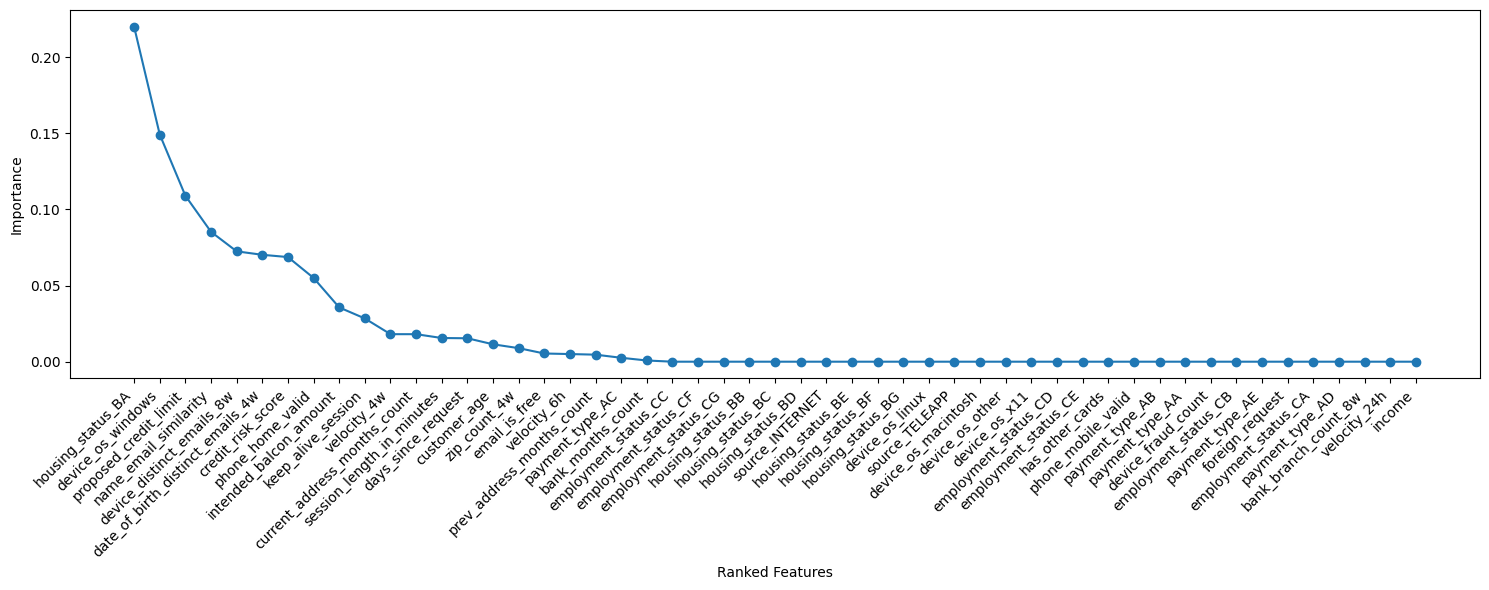

In [719]:
importances = model.feature_importances_     
labels = np.array(feature_names)             
                                             
order = np.argsort(importances)[::-1]        
sorted_importances = importances[order]      
sorted_labels = labels[order]                

plt.figure(figsize=(15, 6))                                
plt.plot(range(1, len(sorted_importances) +  
1), sorted_importances, marker="o")          
plt.xticks(range(1, len(sorted_labels) + 1), 
sorted_labels, rotation=45, ha="right")      
plt.ylabel("Importance")                     
plt.xlabel("Ranked Features")                
plt.tight_layout()                           
plt.show()  

In [720]:
selected_features = importance_df.loc[importance_df['Importance']>0, 'Feature']
X_train = X_train[selected_features]
X_test = X_test[selected_features]
# X_train.shape[1]

feature_names = X_train.columns.tolist()
n_features = len(feature_names)

n_features


21

In [721]:
model = model_used

model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, probs)

target_fpr = target_fpr_value
baseline_recall_at_fpr = 0.0

if np.any(fpr <= target_fpr):
    valid_indices = np.where(fpr <= target_fpr)[0] #where returns a tuple
    best_index = valid_indices[np.argmax(tpr[valid_indices])]
    baseline_tpr_at_fpr = tpr[best_index]

# plt.figure(figsize=(20,10))
# plot_tree(model, feature_names=feature_names, class_names=['No Fraud', 'Fraud'], filled=True)
# plt.savefig("tree_based.svg", format='svg')

print(f"TPR: {baseline_tpr_at_fpr}")

TPR: 0.1968390804597701


### Grammar

In [722]:
class Value(ABC):
    def evaluate(self):
        pass

class Scalar(ABC):
    pass

class Vectorial(ABC):
    pass

In [723]:
random_col = X_train.iloc[:, 3].to_numpy()

random_col_rev = random_col[::-1]

past_values_col = sliding_window_view(random_col_rev, window_shape=3)[::-1, ::-1]
max_past_values_col = past_values_col.mean(axis=1)

mean_past_values = np.cumsum(random_col[:2]) / np.arange(1, 3)
max_past_values_col = np.concatenate((mean_past_values, max_past_values_col))

print(random_col[:8])
print(random_col.shape)
print(random_col_rev[:8])
print(past_values_col[:8])
print(past_values_col.shape)
print(max_past_values_col[:8])
print(max_past_values_col.shape)

[0.98650631 0.61742601 0.99670702 0.47509995 0.84230684 0.29484046
 0.77308547 0.15388043]
(397039,)
[0.84911719 0.64601568 0.51031198 0.98800471 0.08644565 0.21663363
 0.4383583  0.36618424]
[[0.98650631 0.61742601 0.99670702]
 [0.61742601 0.99670702 0.47509995]
 [0.99670702 0.47509995 0.84230684]
 [0.47509995 0.84230684 0.29484046]
 [0.84230684 0.29484046 0.77308547]
 [0.29484046 0.77308547 0.15388043]
 [0.77308547 0.15388043 0.52365466]
 [0.15388043 0.52365466 0.83447459]]
(397037, 3)
[0.98650631 0.80196616 0.86687978 0.69641099 0.77137127 0.53741575
 0.63674426 0.40726879]
(397039,)


In [724]:
@dataclass #Scalar Features (1)
class ScalarVar(Scalar): 
    index: Annotated[int, IntRange(0,n_features-1)]

    def evaluate(self, X_np):
        return X_np[:, self.index]
    
    def __str__(self):
        return feature_names[self.index]
    
@dataclass
class Mean_PastScalarVar(Scalar):
    index: Annotated[int, IntRange(0,n_features-1)]
    lookback: Annotated[int, IntRange(5,15)]

    def evaluate(self, X_np):
        feature_col = X_np[:, self.index]
        feature_col_rev = feature_col[::-1]
        mean = sliding_window_view(feature_col_rev, window_shape=self.lookback)[::-1, ::-1].mean(axis=1)
        mean = np.concatenate((np.cumsum(feature_col[:self.lookback-1]) / np.arange(1, self.lookback), mean))
        return mean

    def __str__(self):
        return f"MeanPast({feature_names[self.index]}, {self.lookback})"
        

# @dataclass #Vectorial Features ([1,2,3,4])
# class VectorialVar(Vectorial):
#     index: Annotated[int, IntRange(1,2)]
    
#     def evaluate(self, X):
#         return X[self.index]

In [725]:
#scalar -> scalar
@dataclass 
class Add(Scalar):
    right: Scalar
    left: Scalar

    def evaluate(self, X_np):
        return self.left.evaluate(X_np) + self.right.evaluate(X_np)
    
    def __str__(self):
        return f"({self.left} + {self.right})"

@dataclass
class Subtract(Scalar):
    right: Scalar
    left: Scalar

    def evaluate(self, X_np):
        return (self.left.evaluate(X_np)) - (self.right.evaluate(X_np))
    
    def __str__(self):
        return f"({self.left} - {self.right})"
    
@dataclass
class Multiply(Scalar):
    right: Scalar
    left: Scalar

    def evaluate(self, X_np):
        return self.left.evaluate(X_np) * self.right.evaluate(X_np)
    
    def __str__(self):
        return f"({self.left} * {self.right})"
    

In [726]:
grammar = extract_grammar([Mean_PastScalarVar, ScalarVar, Add, Subtract, Multiply], Scalar)
# grammar = extract_grammar([ScalarVar, Add, Subtract, Multiply], Scalar)
print(f"Grammar: {repr(grammar)}")

Grammar: Grammar<Starting=Scalar,Productions={
Scalar -> Mean_PastScalarVar(index: Annotated[int], lookback: Annotated[int])|
	ScalarVar(index: Annotated[int])|
	Add(right: Scalar, left: Scalar)|
	Subtract(right: Scalar, left: Scalar)|
	Multiply(right: Scalar, left: Scalar)
}


### Fitness and GP

In [727]:
ARCHIVE_TRAIN_DF = X_train.copy()
ARCHIVE_TEST_DF = X_test.copy()

ARCHIVE_TEMP : list[Individual] = []

In [728]:
X_train_np = ARCHIVE_TRAIN_DF.to_numpy()
X_test_np = ARCHIVE_TEST_DF.to_numpy()

def fitness_function(individual: Value): #individual -> expression
    train_feature = individual.evaluate(X_train_np)
    test_feature = individual.evaluate(X_test_np)
    if train_feature.ndim == 0:
        train_feature = np.full(X_train_np.shape[0], train_feature)
    if test_feature.ndim == 0:
        test_feature = np.full(X_test_np.shape[0], test_feature)

    X_train_augmented = np.c_[X_train_np, np.array(train_feature).reshape(-1,1)]
    X_test_augmented = np.c_[X_test_np, np.array(test_feature).reshape(-1,1)]

    model = model_used
    
    model.fit(X_train_augmented, y_train)

    # train_probs = model.predict_proba(X_train_augmented)[:, 1]

    # fpr, tpr, thresholds = roc_curve(y_train, train_probs)

    # target_fpr = target_fpr_value

    # if np.any(fpr <= target_fpr):
    #     valid_indices = np.where(fpr<=target_fpr)[0]
    #     best_indice = valid_indices[np.argmax(tpr[valid_indices])]
    #     tpr_at_fpr_train = tpr[best_indice]
    
    probs = model.predict_proba(X_test_augmented)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, probs)

    if np.any(fpr <= target_fpr):
        valid_indices = np.where(fpr<=target_fpr)[0]
        best_indice = valid_indices[np.argmax(tpr[valid_indices])]
        tpr_at_fpr = tpr[best_indice]

    tpr_diff = tpr_at_fpr-baseline_tpr_at_fpr
    # print(tpr_diff, tpr_at_fpr, baseline_tpr_at_fpr)
    # train_tpr_diff = tpr_at_fpr_train - train_tpr_at_fpr

    # if tpr_diff < 0:
        # plt.figure(figsize=(20,10))
        # plot_tree(model, feature_names=feature_names + [str(individual)], class_names=['No Fraud', 'Fraud'], filled=True)
        # plt.savefig(f"tree_negative.svg", format='svg')
        
    features, num_operations = analyse_complexity(individual)

    # num_features = len(features)

    # return [tpr_at_fpr, tpr_diff, tpr_at_fpr_train, train_tpr_diff, num_operations]
    return [tpr_at_fpr, tpr_diff, num_operations]



In [729]:
def analyse_complexity(individual: Value):
    if isinstance(individual, ScalarVar) or isinstance(individual, Mean_PastScalarVar):
        return {individual.index}, 0 #unique feature
    
    total_features = set()
    total_operations = 1
    if hasattr(individual, 'left') and hasattr(individual, 'right'):
        left_features, left_operations = analyse_complexity(individual.left)
        right_features, right_operations = analyse_complexity(individual.right)
        total_features.update(left_features)
        total_features.update(right_features)
        total_operations += left_operations + right_operations
    elif hasattr(individual, 'arr'):
        arr_features, arr_operations = analyse_complexity(individual.arr)
        total_features.update(arr_features)
        total_operations += arr_operations
    return total_features, total_operations


In [730]:
class ArchiveStep(GeneticStep):
    def iterate(
        self,
        problem: Problem,
        evaluator: Evaluator,
        representation: Representation,
        random: RandomSource,
        population: Iterator[PhenotypicIndividual],
        target_size: int,
        generation: int,
    ) -> Iterator[PhenotypicIndividual]:
        global ARCHIVE_TEMP, train_tpr_at_fpr, baseline_tpr_at_fpr, ARCHIVE_TRAIN_DF, ARCHIVE_TEST_DF, X_train_np, X_test_np
        if generation == 1:
            best_fitness = 0.0    
            for i,individual in enumerate(population):
                if individual.get_fitness(problem).fitness_components[1] > best_fitness:
                    best_fitness = individual.get_fitness(problem).fitness_components[1]
                    if ARCHIVE_TEMP:
                        ARCHIVE_TEMP[0] = individual
                    else:
                        ARCHIVE_TEMP.append(individual)
                    print("New Individual:", str(individual.get_phenotype()), "Fitness:", individual.get_fitness(problem).fitness_components)
                yield individual
        
        else:
            for i, individual in enumerate(population):
                if individual.get_fitness(problem).fitness_components[1] > 0:
                    print("New Individual:", str(individual.get_phenotype()), "Fitness:", individual.get_fitness(problem).fitness_components)
                    ARCHIVE_TEMP.append(individual)
                yield individual

        if ARCHIVE_TEMP:
            print(f"Archive Size: {len(ARCHIVE_TEMP)}")
            for ind in ARCHIVE_TEMP:
                train_feature_new = ind.get_phenotype().evaluate(X_train_np)
                test_feature_new = ind.get_phenotype().evaluate(X_test_np)

                ARCHIVE_TRAIN_DF[str(ind)] = train_feature_new
                ARCHIVE_TEST_DF[str(ind)] = test_feature_new

            print(ARCHIVE_TRAIN_DF.columns)

            ARCHIVE_TRAIN_DF = ARCHIVE_TRAIN_DF.loc[:, ~ARCHIVE_TRAIN_DF.columns.duplicated()]
            ARCHIVE_TEST_DF = ARCHIVE_TEST_DF.loc[:, ~ARCHIVE_TEST_DF.columns.duplicated()]

            ARCHIVE_TRAIN_DF.columns = [str(col) for col in ARCHIVE_TRAIN_DF.columns]
            ARCHIVE_TEST_DF.columns = [str(col) for col in ARCHIVE_TEST_DF.columns]

            model = model_used
            model.fit(ARCHIVE_TRAIN_DF, y_train)
            # train_probs = model.predict_proba(ARCHIVE_TRAIN_DF)[:,1]
            # fpr, tpr, thresholds = roc_curve(y_train, train_probs)
            target_fpr = target_fpr_value
            # if np.any(fpr <= target_fpr):
            #     valid_indices = np.where(fpr <= target_fpr)[0]
            #     best_index = valid_indices[np.argmax(tpr[valid_indices])]
            #     train_tpr_at_fpr = tpr[best_index]
            probs = model.predict_proba(ARCHIVE_TEST_DF)[:,1]
            fpr, tpr, thresholds = roc_curve(y_test, probs)
            if np.any(fpr <= target_fpr):
                valid_indices = np.where(fpr <= target_fpr)[0]
                best_index = valid_indices[np.argmax(tpr[valid_indices])]
                baseline_tpr_at_fpr = tpr[best_index]
            print(f"Test TPR: {baseline_tpr_at_fpr}, Test shape: {ARCHIVE_TEST_DF.shape}")
            # print(f"Train TPR: {train_tpr_at_fpr}, Train shape: {ARCHIVE_TRAIN_DF.shape}")
            ARCHIVE_TEMP = []
            X_train_np = ARCHIVE_TRAIN_DF.to_numpy()
            X_test_np = ARCHIVE_TEST_DF.to_numpy()


        

In [ ]:
def lexicase_step():
    return SequenceStep(
        ArchiveStep(),
        ParallelStep(
            [
                ElitismStep(),
                NoveltyStep(),
                SequenceStep(
                    LexicaseSelection(epsilon=True),
                    GenericCrossoverStep(0.9),
                    GenericMutationStep(0.1),
                )
            ],
            weights=[0.05, 0.05, 0.9]
        ),
    )

prob = MultiObjectiveProblem(
    fitness_function=fitness_function,
    # minimize=[False, False, False, False, True],
    minimize=[False, False, True],
)
r = NativeRandomSource(123)
alg = GeneticProgramming(
    problem=prob,
    budget=TimeBudget(100),
    population_size=50,
    representation=TreeBasedRepresentation(grammar, MaxDepthDecider(r, grammar, 4)),
    random=r,
    step=lexicase_step(),
    tracker=ProgressTracker(
        prob,
        recorders=[CSVSearchRecorder(
            csv_path='feedzai_output_pastvalues.csv', 
            problem=prob, 
            fields={
                    # "Eval Time": lambda t,i,p: i.get_fitness(p).fitness_components[3],
                    # "TPR Train": lambda t,i,p: i.get_fitness(p).fitness_components[2],
                    # "TPR Train Diff": lambda t,i,p: i.get_fitness(p).fitness_components[3],
                    "TPR Test": lambda t,i,p: i.get_fitness(p).fitness_components[0],
                    "TPR Test Diff": lambda t,i,p: i.get_fitness(p).fitness_components[1],
                    "Expression": lambda t, i, p: i.get_phenotype(),
                    "Num Operations": lambda t,i,p: i.get_fitness(p).fitness_components[2],
                    'Generation': lambda t,i,p: i.metadata["generation"]
                    },
            only_record_best_individuals=False)]
    )
    
)

solutions = alg.search()

TypeError: GeneticProgramming.__init__() missing 1 required positional argument: 'budget'

In [733]:
model = model_used
model.fit(ARCHIVE_TRAIN_DF, y_train)
train_probs = model.predict_proba(ARCHIVE_TRAIN_DF)[:,1]
fpr, tpr, thresholds = roc_curve(y_train, train_probs)
target_fpr = target_fpr_value
if np.any(fpr <= target_fpr):
    valid_indices = np.where(fpr <= target_fpr)[0]
    best_index = valid_indices[np.argmax(tpr[valid_indices])]
    train_tpr_at_fpr = tpr[best_index]
probs = model.predict_proba(ARCHIVE_TEST_DF)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
if np.any(fpr <= target_fpr):
    valid_indices = np.where(fpr <= target_fpr)[0]
    best_index = valid_indices[np.argmax(tpr[valid_indices])]
    baseline_tpr_at_fpr = tpr[best_index]
print(f"Test TPR: {baseline_tpr_at_fpr}, Test shape: {ARCHIVE_TEST_DF.shape}")
# print(f"Train TPR: {train_tpr_at_fpr}, Train shape: {ARCHIVE_TRAIN_DF.shape}")

Test TPR: 0.41379310344827586, Test shape: (150936, 40)


In [735]:
#make a copy of the dataframe ARCHIVE_TRAIN_DF and ARCHIVE_TEST_DF
ARCHIVE_TRAIN_DF_final = ARCHIVE_TRAIN_DF.copy()
ARCHIVE_TEST_DF_final = ARCHIVE_TEST_DF.copy()

In [763]:


def tpr_at_fpr(y_true, y_score, target_fpr=0.05):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    if np.any(fpr <= target_fpr):
        valid_indices = np.where(fpr <= target_fpr)[0]
        best_index = valid_indices[np.argmax(tpr[valid_indices])]
        return tpr[best_index]
    else:
        return 0.0

def scorer(estimator, X, y):
    probs = estimator.predict_proba(X)[:,1]
    return tpr_at_fpr(y, probs, target_fpr=0.05)

search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions={
        'max_depth': [4,6,8,10],
        'min_samples_split': [2,5,10,20],
        'min_samples_leaf': [1,2,4,8],
        'max_features': ['sqrt', 'log2', None],
        'criterion': ['gini', 'entropy']
    },
    n_iter=100,
    scoring=scorer,
    cv=2,
    verbose=3,
)

search.fit(ARCHIVE_TRAIN_DF_final, y_train)

Fitting 2 folds for each of 100 candidates, totalling 200 fits
[CV 1/2] END criterion=gini, max_depth=4, max_features=None, min_samples_leaf=8, min_samples_split=5;, score=0.298 total time=   3.4s
[CV 2/2] END criterion=gini, max_depth=4, max_features=None, min_samples_leaf=8, min_samples_split=5;, score=0.311 total time=   3.1s
[CV 1/2] END criterion=gini, max_depth=4, max_features=sqrt, min_samples_leaf=2, min_samples_split=5;, score=0.149 total time=   0.6s
[CV 2/2] END criterion=gini, max_depth=4, max_features=sqrt, min_samples_leaf=2, min_samples_split=5;, score=0.148 total time=   0.6s
[CV 1/2] END criterion=gini, max_depth=6, max_features=None, min_samples_leaf=8, min_samples_split=20;, score=0.325 total time=   4.3s
[CV 2/2] END criterion=gini, max_depth=6, max_features=None, min_samples_leaf=8, min_samples_split=20;, score=0.358 total time=   4.3s
[CV 1/2] END criterion=entropy, max_depth=6, max_features=None, min_samples_leaf=2, min_samples_split=5;, score=0.331 total time=  

RandomizedSearchCV(cv=2, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=100,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [4, 6, 8, 10],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20]},
                   scoring=<function scorer at 0x000001E0FB717600>, verbose=3)

In [764]:
best_tree = search.best_estimator_
best_score = search.best_score_
print(best_tree, best_score)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=8, min_samples_split=20,
                       random_state=42) 0.34163244353182753
